In [45]:
# General packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# NLP packages
import nltk
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
df = pd.read_json("/content/drive/MyDrive/Data Mining Final Project/Cell_Phones_and_Accessories_5.json", lines=True)

In [3]:
df.head()

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,A30TL5EWN6DFXT,120401325X,christina,"[0, 0]",They look good and stick good! I just don't li...,4,Looks Good,1400630400,"05 21, 2014"
1,ASY55RVNIL0UD,120401325X,emily l.,"[0, 0]",These stickers work like the review says they ...,5,Really great product.,1389657600,"01 14, 2014"
2,A2TMXE2AFO7ONB,120401325X,Erica,"[0, 0]",These are awesome and make my phone look so st...,5,LOVE LOVE LOVE,1403740800,"06 26, 2014"
3,AWJ0WZQYMYFQ4,120401325X,JM,"[4, 4]",Item arrived in great time and was in perfect ...,4,Cute!,1382313600,"10 21, 2013"
4,ATX7CZYFXI1KW,120401325X,patrice m rogoza,"[2, 3]","awesome! stays on, and looks great. can be use...",5,leopard home button sticker for iphone 4s,1359849600,"02 3, 2013"


In [4]:
df.shape

(194439, 9)

## Performing basic analysis of the data


### Words per Review


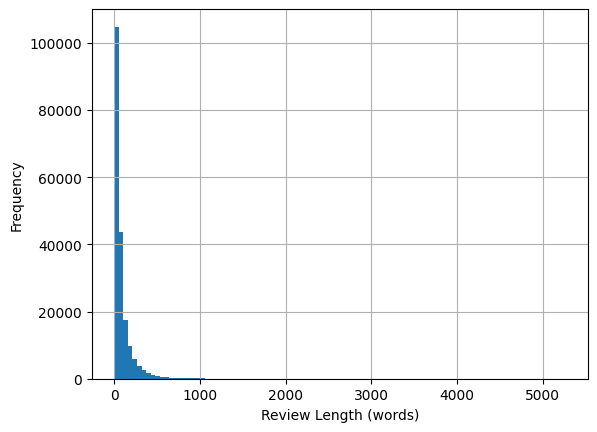

In [5]:
## Getting the number of words by splitting them by a space
words_per_review = df['reviewText'].str.split().str.len()
words_per_review.hist(bins = 100)
plt.xlabel('Review Length (words)')
plt.ylabel('Frequency')
plt.show()

In [6]:

print('Average words:', words_per_review.mean())
print('Skewness:', words_per_review.skew())

Average words: 91.59511209170999
Skewness: 7.484498307316045


### Distribution of ratings:


In [7]:
# Distribution of ratings:
percent_val = 100 * df['overall'].value_counts()/len(df)
percent_val

,count
overall,
5,55.885908
4,20.568404
3,11.026080
1,6.829391
2,5.690216


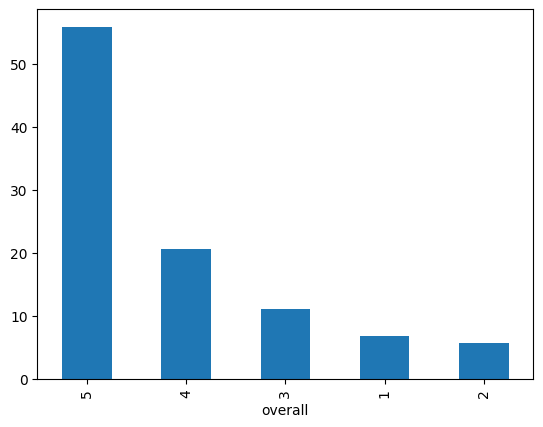

In [8]:
percent_val.plot.bar()
plt.show()

### Text visualization using word cloud


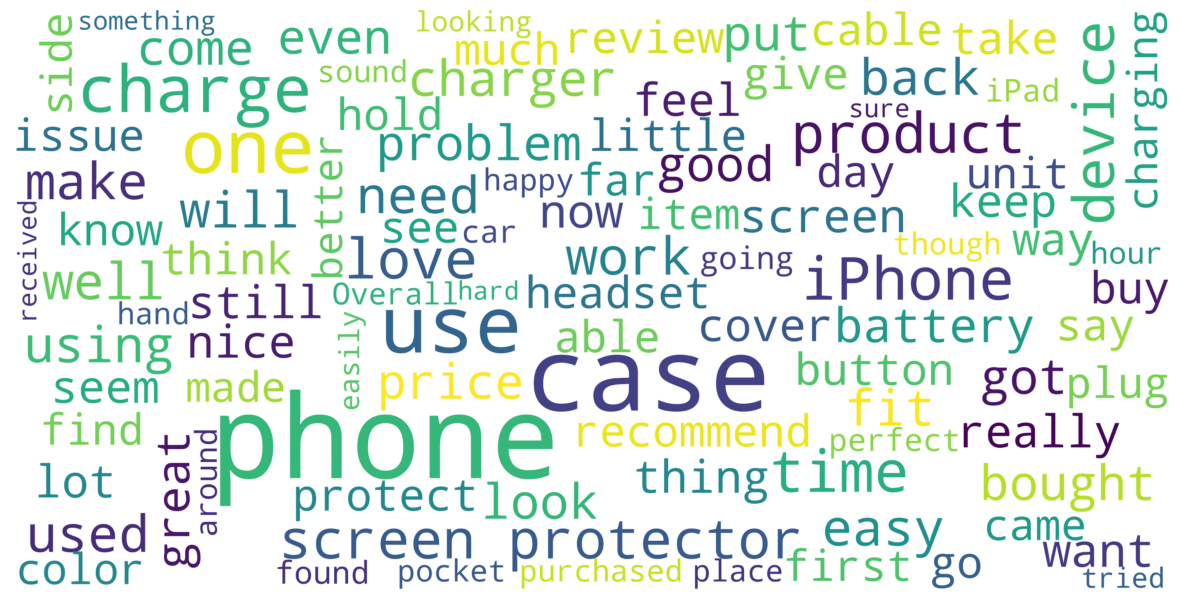

In [9]:
word_cloud_text = ''.join([str(x) for x in df['reviewText']])

wordcloud = WordCloud(max_font_size=100, # Maximum font size for the largest word
                      max_words=100, # The maximum number of words
                      background_color="white", # Background color for the word cloud image
                      scale = 10, # Scaling between computation and drawing
                      width=1000, # Width of the canvas
                      height=500 # Height of the canvas
                     ).generate(word_cloud_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud,
           interpolation="bilinear") # to make the displayed image appear more smoothly
plt.axis("off")
plt.show()

## Standardizing the ratings for sentiment analysis


In [10]:
df['overall'].value_counts()

,count
overall,
5,108664
4,39993
3,21439
1,13279
2,11064


In [11]:
# Mapping the ratings to 3-class sentiment (Positive / Neutral / Negative)
# 4-5 stars -> positive, 3 stars -> neutral, 1-2 stars -> negative

def rating_to_sentiment(rating):
    if rating > 3:
        return "positive"
    elif rating == 3:
        return "neutral"
    else:
        return "negative"

df['Sentiment_rating'] = df['overall'].apply(rating_to_sentiment)

In [12]:
df['Sentiment_rating'].value_counts()

,count
Sentiment_rating,
positive,148657
negative,24343
neutral,21439


## Data Preprocessing


In [14]:
# Removing unneccessary columns
df.drop(['reviewerID', 'asin', 'reviewerName', 'helpful','summary', 'unixReviewTime', 'reviewTime'],axis='columns',inplace=True)

In [15]:
df= df.rename(columns={"reviewText":"Review","overall": "Rating"})

In [16]:
df.head()

,Review,Rating,Sentiment_rating
0,They look good and stick good! I just don't li...,4,positive
1,These stickers work like the review says they ...,5,positive
2,These are awesome and make my phone look so st...,5,positive
3,Item arrived in great time and was in perfect ...,4,positive
4,"awesome! stays on, and looks great. can be use...",5,positive


### 1. Converting words to lowercase


In [17]:
df['Review_New'] = df['Review'].str.lower()

In [18]:
df.iloc[:,[0,3]]

,Review,Review_New
0,They look good and stick good! I just don't li...,they look good and stick good! i just don't li...
1,These stickers work like the review says they ...,these stickers work like the review says they ...
2,These are awesome and make my phone look so st...,these are awesome and make my phone look so st...
3,Item arrived in great time and was in perfect ...,item arrived in great time and was in perfect ...
4,"awesome! stays on, and looks great. can be use...","awesome! stays on, and looks great. can be use..."
...,...,...
194434,Works great just like my original one. I reall...,works great just like my original one. i reall...
194435,Great product. Great packaging. High quality a...,great product. great packaging. high quality a...
194436,"This is a great cable, just as good as the mor...","this is a great cable, just as good as the mor..."
194437,I really like it becasue it works well with my...,i really like it becasue it works well with my...


### 2. Removing special characters


In [19]:
# Selecting non alpha numeric characters that are not spaces

spl_charcs = df['Review_New'].apply(lambda review:
                                           [char for char in list(review) if not char.isalnum() and char != ' '])

# Getting list of list into a single list
flat_list = [item for sublist in spl_charcs for item in sublist]

## Unique special characters
set(flat_list)

{'\x10',
 '\x1d',
 '!',
 '"',
 '#',
 '$',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 ':',
 ';',
 '=',
 '>',
 '?',
 '@',
 '[',
 '\\',
 ']',
 '^',
 '_',
 '`',
 '{',
 '|',
 '}',
 '~'}

In [20]:
review_backup = df['Review_New'].copy()
df['Review_New'] = df['Review_New'].str.replace(r'[^A-Za-z0-9 ]+',' ', regex=True)

In [21]:
review_backup

,Review_New
0,they look good and stick good! i just don't li...
1,these stickers work like the review says they ...
2,these are awesome and make my phone look so st...
3,item arrived in great time and was in perfect ...
4,"awesome! stays on, and looks great. can be use..."
...,...
194434,works great just like my original one. i reall...
194435,great product. great packaging. high quality a...
194436,"this is a great cable, just as good as the mor..."
194437,i really like it becasue it works well with my...


In [22]:
idx_to_show = review_backup.index[0]
print("- Old Review -")
print(review_backup.loc[idx_to_show])
print("\n - New Review -")
print(df['Review_New'].loc[idx_to_show])

- Old Review -
they look good and stick good! i just don't like the rounded shape because i was always bumping it and siri kept popping up and it was irritating. i just won't buy a product like this again

 - New Review -
they look good and stick good  i just don t like the rounded shape because i was always bumping it and siri kept popping up and it was irritating  i just won t buy a product like this again


In [23]:
# Apply word tokenizer
# For reviews not converted to lower case
tokens_list = [word_tokenize(each) for each in df['Review']]
tokens = [item for sublist in tokens_list for item in sublist]
print("Number of unique tokens then: ", len(set(tokens)))

# For reviews converted to lower case
tokens_list_lower = [word_tokenize(each) for each in df['Review_New']]
tokens_lower = [item for sublist in tokens_list_lower for item in sublist]
print("Number of unique tokens now: ", len(set(tokens_lower)))

Number of unique tokens then:  232590
Number of unique tokens now:  86500


### 3. Stopwords and high/low frequency words


In [24]:

noise_words = []
eng_stop_words = stopwords.words('english')
eng_stop_words

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [25]:
df.head()

,Review,Rating,Sentiment_rating,Review_New
0,They look good and stick good! I just don't li...,4,positive,they look good and stick good i just don t li...
1,These stickers work like the review says they ...,5,positive,these stickers work like the review says they ...
2,These are awesome and make my phone look so st...,5,positive,these are awesome and make my phone look so st...
3,Item arrived in great time and was in perfect ...,4,positive,item arrived in great time and was in perfect ...
4,"awesome! stays on, and looks great. can be use...",5,positive,awesome stays on and looks great can be use...


In [26]:
# Example of stop words in a sentence

stop_words = set(eng_stop_words)
without_stop_words = []
stopword = []
sentence = df['Review_New'].loc[df.index[0]] # Using .loc with the first valid index
words = nltk.word_tokenize(sentence)

for word in words:
    if word in stop_words:
        stopword.append(word)
    else:
        without_stop_words.append(word)

print("---- Original Sentence ----\n", sentence)
print("\n---- Stopwords in the sentence ----\n", stopword)
print("\n---- Non-stopwords in the sentence ----\n", without_stop_words)

---- Original Sentence ----
 they look good and stick good  i just don t like the rounded shape because i was always bumping it and siri kept popping up and it was irritating  i just won t buy a product like this again

---- Stopwords in the sentence ----
 ['they', 'and', 'i', 'just', 'don', 't', 'the', 'because', 'i', 'was', 'it', 'and', 'up', 'and', 'it', 'was', 'i', 'just', 'won', 't', 'a', 'this', 'again']

---- Non-stopwords in the sentence ----
 ['look', 'good', 'stick', 'good', 'like', 'rounded', 'shape', 'always', 'bumping', 'siri', 'kept', 'popping', 'irritating', 'buy', 'product', 'like']


In [27]:
# Removing stop words from our review column
def stopwords_removal(stop_words, sentence):
    return [word for word in nltk.word_tokenize(sentence) if word not in stop_words]

df['Review_Text_NonStop'] = df['Review_New'].apply(lambda row: stopwords_removal(stop_words, row))
df[['Review_New','Review_Text_NonStop']]


,Review_New,Review_Text_NonStop
0,they look good and stick good i just don t li...,"[look, good, stick, good, like, rounded, shape..."
1,these stickers work like the review says they ...,"[stickers, work, like, review, says, stick, gr..."
2,these are awesome and make my phone look so st...,"[awesome, make, phone, look, stylish, used, on..."
3,item arrived in great time and was in perfect ...,"[item, arrived, great, time, perfect, conditio..."
4,awesome stays on and looks great can be use...,"[awesome, stays, looks, great, used, multiple,..."
...,...,...
194434,works great just like my original one i reall...,"[works, great, like, original, one, really, ne..."
194435,great product great packaging high quality a...,"[great, product, great, packaging, high, quali..."
194436,this is a great cable just as good as the mor...,"[great, cable, good, expensive, apple, one, hu..."
194437,i really like it becasue it works well with my...,"[really, like, becasue, works, well, life, pro..."


### 4. Stemming & Lemmatization


In [28]:
from nltk.stem import LancasterStemmer
from nltk.corpus import wordnet

lancaster = LancasterStemmer()
lemmatizer = WordNetLemmatizer()

In [29]:
# Example of stemming & lemmatization

print("Lancaster Stemmer")
print(lancaster.stem("divide"))
print(lancaster.stem("divided"))
print(lancaster.stem("dividing"))

# Provide a word to  be lemmatized
print("Wordnet Lemmatizer")
print(lemmatizer.lemmatize("divide", wordnet.NOUN))
print(lemmatizer.lemmatize("divided", wordnet.VERB))
print(lemmatizer.lemmatize("dividing", wordnet.VERB))

Lancaster Stemmer
divid
divid
divid
Wordnet Lemmatizer
divide
divide
divide


In [30]:
# Apply stemming & lemmatization
def stemm_terms(row):
    return [lancaster.stem(term) for term in row]
def lemmatize_terms(row):
    return [lemmatizer.lemmatize(term) for term in row]
df['Review_Text_Stemm'] = df['Review_Text_NonStop'].apply(lambda row: stemm_terms(row))
df['Review_Text_Lemm'] = df['Review_Text_NonStop'].apply(lambda row: lemmatize_terms(row))
df[['Review_Text_NonStop','Review_Text_Stemm','Review_Text_Lemm']]

,Review_Text_NonStop,Review_Text_Stemm,Review_Text_Lemm
0,"[look, good, stick, good, like, rounded, shape...","[look, good, stick, good, lik, round, shap, al...","[look, good, stick, good, like, rounded, shape..."
1,"[stickers, work, like, review, says, stick, gr...","[stick, work, lik, review, say, stick, gre, st...","[sticker, work, like, review, say, stick, grea..."
2,"[awesome, make, phone, look, stylish, used, on...","[awesom, mak, phon, look, styl, us, on, far, a...","[awesome, make, phone, look, stylish, used, on..."
3,"[item, arrived, great, time, perfect, conditio...","[item, ar, gre, tim, perfect, condit, howev, o...","[item, arrived, great, time, perfect, conditio..."
4,"[awesome, stays, looks, great, used, multiple,...","[awesom, stay, look, gre, us, multipl, appl, p...","[awesome, stay, look, great, used, multiple, a..."
...,...,...,...
194434,"[works, great, like, original, one, really, ne...","[work, gre, lik, origin, on, real, nee, extra,...","[work, great, like, original, one, really, nee..."
194435,"[great, product, great, packaging, high, quali...","[gre, produc, gre, pack, high, qual, appl, cer...","[great, product, great, packaging, high, quali..."
194436,"[great, cable, good, expensive, apple, one, hu...","[gre, cabl, good, expend, appl, on, husband, d...","[great, cable, good, expensive, apple, one, hu..."
194437,"[really, like, becasue, works, well, life, pro...","[real, lik, becasu, work, wel, lif, proof, cas...","[really, like, becasue, work, well, life, proo..."


In [31]:
df.head(15)

,Review,Rating,Sentiment_rating,Review_New,Review_Text_NonStop,Review_Text_Stemm,Review_Text_Lemm
0,They look good and stick good! I just don't li...,4,positive,they look good and stick good i just don t li...,"[look, good, stick, good, like, rounded, shape...","[look, good, stick, good, lik, round, shap, al...","[look, good, stick, good, like, rounded, shape..."
1,These stickers work like the review says they ...,5,positive,these stickers work like the review says they ...,"[stickers, work, like, review, says, stick, gr...","[stick, work, lik, review, say, stick, gre, st...","[sticker, work, like, review, say, stick, grea..."
2,These are awesome and make my phone look so st...,5,positive,these are awesome and make my phone look so st...,"[awesome, make, phone, look, stylish, used, on...","[awesom, mak, phon, look, styl, us, on, far, a...","[awesome, make, phone, look, stylish, used, on..."
3,Item arrived in great time and was in perfect ...,4,positive,item arrived in great time and was in perfect ...,"[item, arrived, great, time, perfect, conditio...","[item, ar, gre, tim, perfect, condit, howev, o...","[item, arrived, great, time, perfect, conditio..."
4,"awesome! stays on, and looks great. can be use...",5,positive,awesome stays on and looks great can be use...,"[awesome, stays, looks, great, used, multiple,...","[awesom, stay, look, gre, us, multipl, appl, p...","[awesome, stay, look, great, used, multiple, a..."
5,These make using the home button easy. My daug...,3,neutral,these make using the home button easy my daug...,"[make, using, home, button, easy, daughter, li...","[mak, us, hom, button, easy, daught, lik, woul...","[make, using, home, button, easy, daughter, li..."
6,Came just as described.. It doesn't come unstu...,5,positive,came just as described it doesn t come unstuc...,"[came, described, come, unstuck, cute, people,...","[cam, describ, com, unstuck, cut, peopl, ask, ...","[came, described, come, unstuck, cute, people,..."
7,it worked for the first week then it only char...,1,negative,it worked for the first week then it only char...,"[worked, first, week, charge, phone, 20, waste...","[work, first, week, charg, phon, 20, wast, money]","[worked, first, week, charge, phone, 20, waste..."
8,"Good case, solid build. Protects phone all aro...",5,positive,good case solid build protects phone all aro...,"[good, case, solid, build, protects, phone, ar...","[good, cas, solid, build, protect, phon, aroun...","[good, case, solid, build, protects, phone, ar..."
9,This is a fantastic case. Very stylish and pro...,5,positive,this is a fantastic case very stylish and pro...,"[fantastic, case, stylish, protects, phone, ea...","[fantast, cas, styl, protect, phon, easy, acce...","[fantastic, case, stylish, protects, phone, ea..."


## Feature Preparation for Modeling

The preprocessing above produced `Review_Text_Lemm` (a list of lemmatized
tokens per review). We join those tokens back into a single string per
review since scikit-learn's TF-IDF vectorizer expects raw text, not
pre-tokenized lists.


In [32]:
df['Review_Final'] = df['Review_Text_Lemm'].apply(lambda tokens: ' '.join(tokens))
df[['Review', 'Sentiment_rating', 'Review_Final']].head()


,Review,Sentiment_rating,Review_Final
0,They look good and stick good! I just don't li...,positive,look good stick good like rounded shape always...
1,These stickers work like the review says they ...,positive,sticker work like review say stick great stay ...
2,These are awesome and make my phone look so st...,positive,awesome make phone look stylish used one far a...
3,Item arrived in great time and was in perfect ...,positive,item arrived great time perfect condition howe...
4,"awesome! stays on, and looks great. can be use...",positive,awesome stay look great used multiple apple pr...


### Checking class balance

Amazon review data is typically skewed heavily toward positive reviews.
We check this here because it affects both how we evaluate the model
(accuracy alone can be misleading) and how we configure the classifier
(`class_weight="balanced"`).


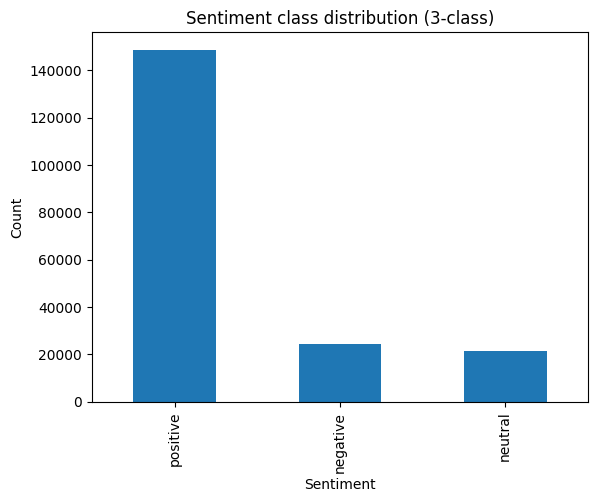

In [34]:
df['Sentiment_rating'].value_counts().plot.bar()
plt.title('Sentiment class distribution (3-class)')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

In [36]:
X = df['Review_Final']
y = df['Sentiment_rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print("\nTrain label distribution:")
print(y_train.value_counts(normalize=True))

Train size: 155551
Test size:  38888

Train label distribution:
Sentiment_rating
positive    0.764547
negative    0.125194
neutral     0.110260
Name: proportion, dtype: float64


## Feature Extraction: TF-IDF

We use TF-IDF (Term Frequency - Inverse Document Frequency) with unigrams
and bigrams, capped at 20,000 features and with English stopwords removed
(on top of the stopword removal already done in preprocessing, this also
strips out reviews vocabulary not covered by NLTK's list).


In [38]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), max_features=20000, stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("TF-IDF matrix shape (test):", X_test_tfidf.shape)

TF-IDF matrix shape (train): (155551, 20000)
TF-IDF matrix shape (test): (38888, 20000)


## Model Training: Logistic Regression

Logistic Regression is a strong, fast, interpretable baseline for text
classification. `class_weight="balanced"` down-weights the majority
(positive) class so the model doesn't just learn to always predict
positive.


In [40]:
log_reg = LogisticRegression(max_iter=1000, class_weight='balanced')
log_reg.fit(X_train_tfidf, y_train)

print("Model trained.")

Model trained.


In [42]:
LABELS = ['negative', 'neutral', 'positive']

y_pred = log_reg.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")
print(classification_report(y_test, y_pred, labels=LABELS, zero_division=0))

Accuracy: 0.7369

              precision    recall  f1-score   support

    negative       0.52      0.68      0.59      4869
     neutral       0.27      0.50      0.35      4288
    positive       0.94      0.78      0.85     29731

    accuracy                           0.74     38888
   macro avg       0.58      0.65      0.60     38888
weighted avg       0.81      0.74      0.76     38888



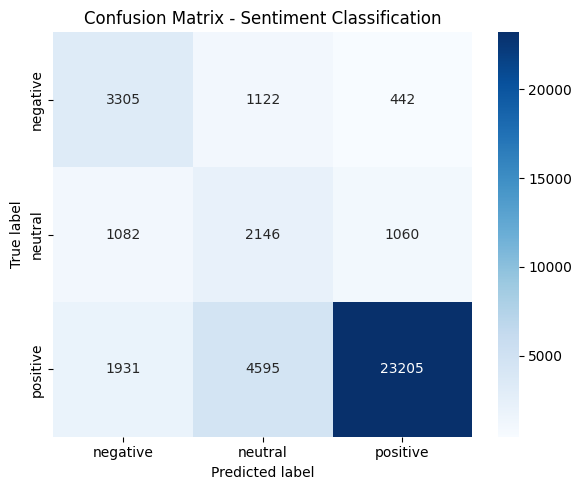

In [43]:
cm = confusion_matrix(y_test, y_pred, labels=LABELS)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=LABELS, yticklabels=LABELS)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix - Sentiment Classification')
plt.tight_layout()
plt.show()

### Top words driving each class

Words which most strongly push the model
towards predicting each sentiment.


In [44]:
feature_names = tfidf.get_feature_names_out()

for i, label in enumerate(log_reg.classes_):
    top_idx = log_reg.coef_[i].argsort()[-15:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f"{label}: {', '.join(top_words)}\n")

negative: returning, useless, worst, returned, poorly, disappointed, poor, return, horrible, awful, terrible, disappointing, junk, worthless, waste

neutral: okay, ok, ultimately, job, little disappointed, meh, unfortunately, mixed, good great, note big, perfect problem, alright, limitation, stretching, better stock

positive: love, great, perfect, excellent, perfectly, awesome, highly, highly recommend, amazing, easy, best, great product, compliment, saved, highly recommended



## Multinomial Naive Bayes Model



In [46]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)
acc_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(f"Logistic Regression Accuracy: {acc:.4f}\n")
print("Naive Bayes classification report:")
print(classification_report(y_test, y_pred_nb, labels=LABELS, zero_division=0))

Naive Bayes Accuracy: 0.7977
Logistic Regression Accuracy: 0.7369

Naive Bayes classification report:
              precision    recall  f1-score   support

    negative       0.76      0.29      0.42      4869
     neutral       0.54      0.02      0.04      4288
    positive       0.80      0.99      0.89     29731

    accuracy                           0.80     38888
   macro avg       0.70      0.44      0.45     38888
weighted avg       0.77      0.80      0.74     38888



## Classifying New Reviews


In [47]:
def clean_and_lemmatize(text):
    """Apply the same cleaning + tokenizing + stopword removal + lemmatization
    used above, to a single new review string."""
    text = text.lower()
    text = re.sub(r'[^A-Za-z0-9 ]+', ' ', text)
    tokens = nltk.word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


def predict_sentiment(texts, model=log_reg):
    cleaned = [clean_and_lemmatize(t) for t in texts]
    features = tfidf.transform(cleaned)
    preds = model.predict(features)
    probs = model.predict_proba(features)
    classes = model.classes_
    for text, pred, prob in zip(texts, preds, probs):
        prob_str = ", ".join(f"{c}: {p:.2f}" for c, p in zip(classes, prob))
        print(f"\nReview: {text}")
        print(f"  -> Predicted sentiment: {pred.upper()}")
        print(f"  -> Confidence: {prob_str}")


predict_sentiment([
    "This phone case broke after two days, total waste of money.",
    "It's okay, does the job but nothing special.",
    "Absolutely love this charger, works perfectly and charges fast!",
])



Review: This phone case broke after two days, total waste of money.
  -> Predicted sentiment: NEGATIVE
  -> Confidence: negative: 1.00, neutral: 0.00, positive: 0.00

Review: It's okay, does the job but nothing special.
  -> Predicted sentiment: NEUTRAL
  -> Confidence: negative: 0.00, neutral: 1.00, positive: 0.00

Review: Absolutely love this charger, works perfectly and charges fast!
  -> Predicted sentiment: POSITIVE
  -> Confidence: negative: 0.00, neutral: 0.00, positive: 0.99
